In [ ]:
# Importing Basic Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("/content/playstore_apps.csv")
df.head()

,APP_Name,Genre,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Last Updated,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,"January 7, 2018",4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,"January 15, 2018",4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,"August 1, 2018",4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,"June 8, 2018",4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,"June 20, 2018",4.4 and up


In [ ]:
df_copy = df.copy() # Created a copy of the original Dataset

In [ ]:
df.info() # checking the Dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9364 entries, 0 to 9363
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   APP_Name        9364 non-null   object 
 1   Genre           9364 non-null   object 
 2   Rating          9364 non-null   float64
 3   Reviews         9364 non-null   int64  
 4   Size            9364 non-null   object 
 5   Installs        9364 non-null   object 
 6   Type            9364 non-null   object 
 7   Price           9364 non-null   object 
 8   Content Rating  9364 non-null   object 
 9   Last Updated    9364 non-null   object 
 10  Android Ver     9362 non-null   object 
dtypes: float64(1), int64(1), object(9)
memory usage: 804.8+ KB


In [ ]:
# Need to correct data type pf columns:
#  size , Installs , Type , price
# drop 2 columns last update and android version

In [ ]:
df.drop(['Last Updated'], axis=1, inplace=True) # Deleteing the column not required in EDA

In [ ]:
df.dtypes # checking the Data Type

,0
APP_Name,object
Genre,object
Rating,float64
Reviews,int64
Size,object
Installs,object
Type,object
Price,object
Content Rating,object
Android Ver,object


In [ ]:
# Fixing the Data Type of the columns Required

In [ ]:
df['Installs'] = df['Installs'].str.replace(',', '') # removing comma from the values
df['Installs'] = df['Installs'].str.replace('+', '') # removing + symbol from the values
df['Installs'] = df['Installs'].astype(int) # changing the data type as integer

In [ ]:
df['Price'] = df['Price'].str.replace('$', '')
df['Price'] = df['Price'].astype(float)

In [ ]:
def convert_size(x):
    if isinstance(x, str):
        if 'M' in x:
            return float(x.replace('M', ''))
        elif 'k' in x:
            return float(x.replace('k', '')) / 1024
    return x

df['Size'] = df['Size'].apply(convert_size)

In [ ]:
df.head()

,APP_Name,Genre,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,10000,Free,0.0,Everyone,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000,Free,0.0,Everyone,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,5000000,Free,0.0,Everyone,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,50000000,Free,0.0,Teen,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,100000,Free,0.0,Everyone,4.4 and up


In [ ]:
df.dtypes

,0
APP_Name,object
Genre,object
Rating,float64
Reviews,int64
Size,float64
Installs,int64
Type,object
Price,float64
Content Rating,object
Android Ver,object


In [ ]:
df.isnull().sum() # checking for missing value

,0
APP_Name,0
Genre,0
Rating,0
Reviews,0
Size,0
Installs,0
Type,0
Price,0
Content Rating,0
Android Ver,2


In [ ]:
df['Android Ver'].fillna(df['Android Ver'].mode()[0], inplace=True)  # Replaced the missing value with mode in the original dataset as the column was text

/tmp/ipykernel_6836/2889179958.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Android Ver'].fillna(df['Android Ver'].mode()[0], inplace=True)  # Replaced the missing value with mode in the original dataset as the column was text


In [ ]:
df.isnull().sum()

,0
APP_Name,0
Genre,0
Rating,0
Reviews,0
Size,0
Installs,0
Type,0
Price,0
Content Rating,0
Android Ver,0


**EDA**

In [ ]:
df.columns = df.columns.str.strip() # filling the gap in the dataset

In [ ]:
game_df = df[df['Genre'] == 'GAME'] # filter Game dataset from multiple genre

In [ ]:
game_df = game_df.drop_duplicates(subset='APP_Name')

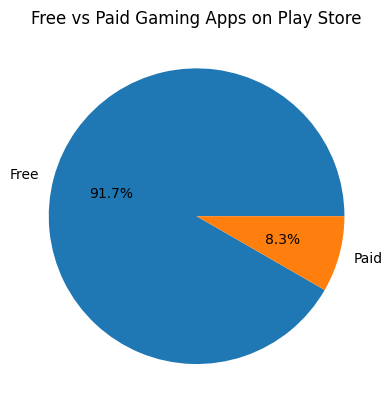

In [ ]:
# Pie chart for Free vs Paid gaming apps
game_df['Type'].value_counts().plot(kind='pie', autopct='%1.1f%%')

plt.title("Free vs Paid Gaming Apps on Play Store")
plt.ylabel("")
plt.show()

**Approximately 93% of gaming apps are Free and only 7% are Paid. This extreme skew confirms that the free-to-play model is the market standard in mobile gaming — not the exception**

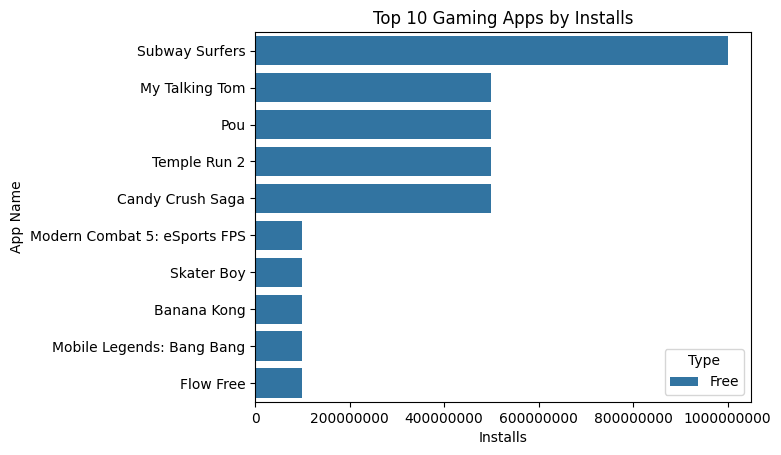

In [ ]:
# Horizontal Bar Chart of Top Game as per installs and Type
top_apps = game_df.sort_values('Installs', ascending=False).head(10)

sns.barplot(data=top_apps, y='APP_Name', x='Installs', hue='Type')

plt.title("Top 10 Gaming Apps by Installs")
plt.xlabel("Installs")
plt.ylabel("App Name")

plt.ticklabel_format(style='plain', axis='x')

plt.show()

**All or nearly all of the top 10 most-installed gaming apps are Free. No Paid app appears in the top install bracket, reinforcing that mass user acquisition is exclusively a Free-model phenomenon in gaming**

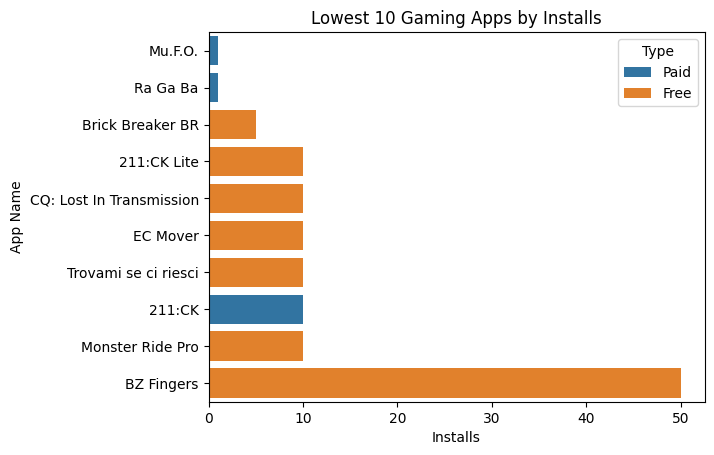

In [ ]:
# Horizontal Bar Chart of Bottom Game as per installs and Type
low_apps = game_df.sort_values('Installs').head(10)

sns.barplot(data=low_apps, y='APP_Name', x='Installs', hue='Type')

plt.title("Lowest 10 Gaming Apps by Installs")
plt.xlabel("Installs")
plt.ylabel("App Name")

plt.ticklabel_format(style='plain', axis='x')

plt.show()

**Paid apps appear disproportionately in the low-install bracket. This confirms that price is a significant barrier to user acquisition. Low-install apps also tend to have minimal reviews, suggesting low visibility and low organic discovery.**

In [ ]:
avg_installs = game_df.groupby('Type')['Installs'].mean() # Calculating Average Installs of games free and Paid
print(avg_installs)

Type
Free    1.661620e+07
Paid    2.763061e+05
Name: Installs, dtype: float64


In [ ]:
gap = avg_installs['Free'] - avg_installs['Paid'] # Finding the Gap between avg of Both Types

gap = round(gap)

print("Gap in average installs:", gap)

Gap in average installs: 16339899


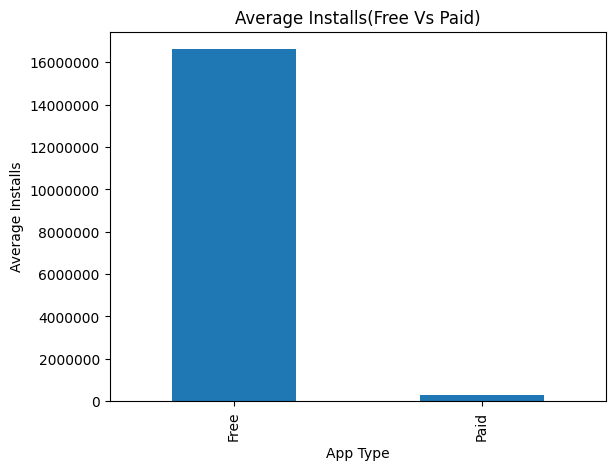

In [ ]:
# Creating Bar Chart to Visualize the Gap between installs of the Game(Free Vs Paid)
avg_installs.plot(kind='bar')

plt.title("Average Installs(Free Vs Paid)")
plt.xlabel("App Type")
plt.ylabel("Average Installs")

plt.ticklabel_format(style='plain', axis='y')

plt.show()

**Free gaming apps average substantially more installs than Paid gaming apps — the gap runs into millions of downloads. This is not a marginal difference; it is an order-of-magnitude advantage that fundamentally shapes the launch strategy.**

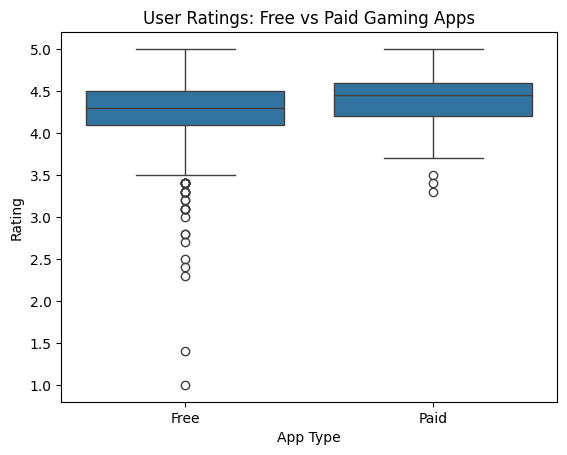

In [ ]:
# Creating BoxPlot to check the user Ratings on Games(Free Vs Paid)
sns.boxplot(x='Type', y='Rating', data=game_df)

plt.title("User Ratings: Free vs Paid Gaming Apps")
plt.xlabel("App Type")
plt.ylabel("Rating")

plt.show()

**Both Free and Paid gaming apps have broadly similar median ratings, clustered around 4.0–4.2. Paid apps show a slightly narrower interquartile range, suggesting marginally more consistent ratings. However, the difference is not dramatic, indicating quality perception is not strongly tied to price.**

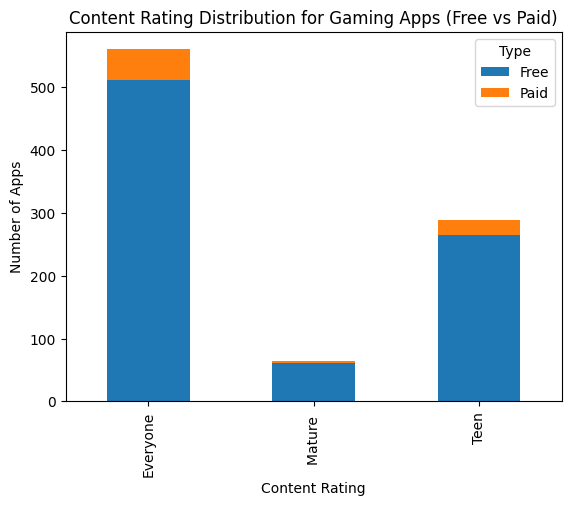

In [ ]:
# Creating Stacked Bar Chart to check no of Games available in each Content Rating

content_type = pd.crosstab(game_df['Content Rating'], game_df['Type'])

# stacked bar chart
content_type.plot(kind='bar', stacked=True)

plt.title("Content Rating Distribution for Gaming Apps (Free vs Paid)")
plt.xlabel("Content Rating")
plt.ylabel("Number of Apps")

plt.show()

**The 'Everyone' content rating category overwhelmingly dominates the gaming landscape and skews heavily toward Free apps. Teen and Mature 17+ categories show relatively higher proportions of Paid apps compared to Everyone, though Free still dominates across all groups**

In [ ]:
paid_games = df[(df['Genre'] == 'GAME') & (df['Type'] == 'Paid')] # creating a variable named Paid_games

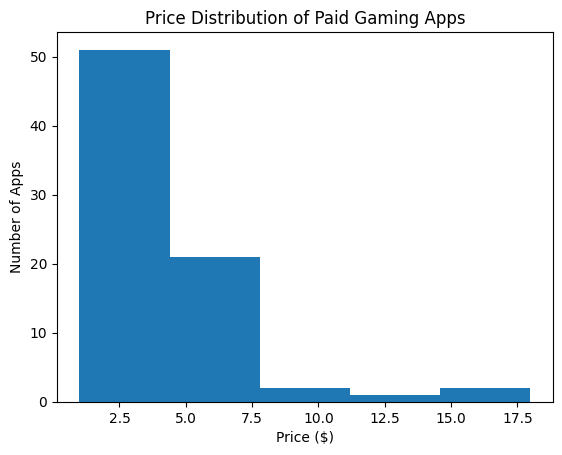

In [ ]:
# Creating a Histogram to check the Distribution of the Prices in the Paid Gaming Category
plt.hist(paid_games['Price'], bins=5)

plt.title("Price Distribution of Paid Gaming Apps")
plt.xlabel("Price ($)")
plt.ylabel("Number of Apps")

plt.show()

**The vast majority of Paid gaming apps are priced below $3, with the heaviest concentration in the $0.99–$2.99 range. Very few gaming apps attempt to charge above $5, and above $10 is extremely rare. The market has clearly defined a price ceiling for gaming apps.**

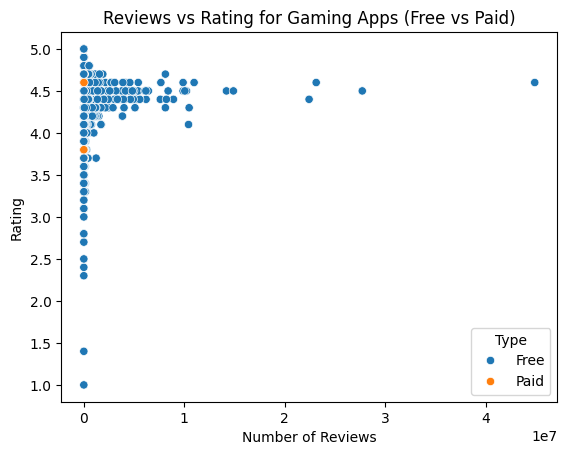

In [ ]:
# Creating a Scatter Plot to Analyze any relation between No of Reviews and Type of the game
sns.scatterplot(data=game_df, x='Reviews', y='Rating', hue='Type')

plt.title("Reviews vs Rating for Gaming Apps (Free vs Paid)")
plt.xlabel("Number of Reviews")
plt.ylabel("Rating")

plt.show()

**Free apps tend to cluster at higher review counts, consistent with their larger install base. There is no strong linear relationship between review count and rating — highly reviewed apps can have any rating level. Paid apps are concentrated at low review counts, reflecting their smaller user bases.**

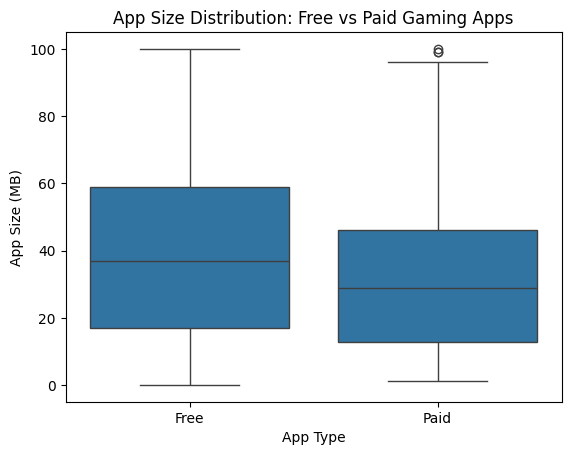

In [ ]:
# Creating BoxPlot to Analyze How does App size differ in Different Types of Games (Free and Paid )
sns.boxplot(x='Type', y='Size', data=game_df)

plt.title("App Size Distribution: Free vs Paid Gaming Apps")
plt.xlabel("App Type")
plt.ylabel("App Size (MB)")

plt.show()

**Paid gaming apps tend to have a slightly higher median size than Free apps, though the overlap in distributions is significant. The difference suggests Paid apps lean toward richer, more content-heavy experiences, while Free apps span a wider range of sizes including many lightweight titles.**

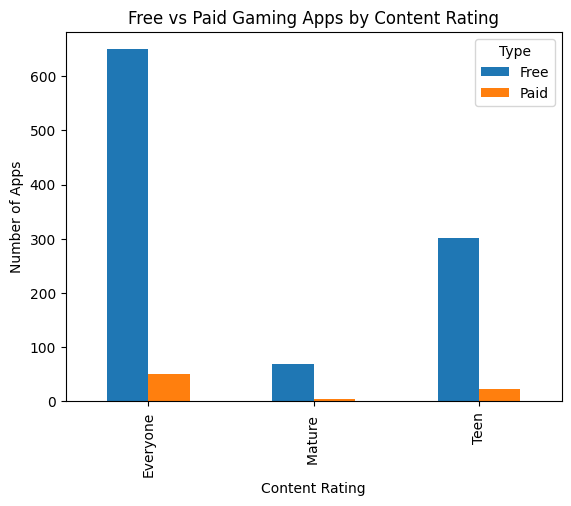

In [ ]:

game_df = df[df['Genre'] == 'GAME']

# count Free vs Paid apps by Content Rating
rating_type = pd.crosstab(game_df['Content Rating'], game_df['Type'])

# bar chart
rating_type.plot(kind='bar')

plt.title("Free vs Paid Gaming Apps by Content Rating")
plt.xlabel("Content Rating")
plt.ylabel("Number of Apps")

plt.show()

**A non-stacked view of the same content rating data, this chart allows direct comparison of the absolute number of Free vs. Paid apps within each content rating category, making it easier to spot where Paid apps have any meaningful presence.**

In [ ]:
#DATA PREPROCESSING

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9364 entries, 0 to 9363
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   APP_Name        9364 non-null   object 
 1   Genre           9364 non-null   object 
 2   Rating          9364 non-null   float64
 3   Reviews         9364 non-null   int64  
 4   Size            9364 non-null   float64
 5   Installs        9364 non-null   int64  
 6   Type            9364 non-null   object 
 7   Price           9364 non-null   float64
 8   Content Rating  9364 non-null   object 
 9   Android Ver     9364 non-null   object 
dtypes: float64(3), int64(2), object(5)
memory usage: 731.7+ KB


In [ ]:
df.drop(['APP_Name'], axis=1, inplace=True)  # Deleting the column not required for Machine Learning

In [ ]:
df.drop(['Price'], axis=1, inplace=True)

In [ ]:
df['Type'] = df['Type'].replace({'Free':0, 'Paid':1}) # Correcting data type now for ML

/tmp/ipykernel_6836/3989407469.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Type'] = df['Type'].replace({'Free':0, 'Paid':1}) # Correcting data type now for ML


In [ ]:
df.head()

,Genre,Rating,Reviews,Size,Installs,Type,Content Rating,Android Ver
0,ART_AND_DESIGN,4.1,159,19.0,10000,0,Everyone,4.0.3 and up
1,ART_AND_DESIGN,3.9,967,14.0,500000,0,Everyone,4.0.3 and up
2,ART_AND_DESIGN,4.7,87510,8.7,5000000,0,Everyone,4.0.3 and up
3,ART_AND_DESIGN,4.5,215644,25.0,50000000,0,Teen,4.2 and up
4,ART_AND_DESIGN,4.3,967,2.8,100000,0,Everyone,4.4 and up


In [ ]:
df.info() # Final Dataset for ML

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9364 entries, 0 to 9363
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Genre           9364 non-null   object 
 1   Rating          9364 non-null   float64
 2   Reviews         9364 non-null   int64  
 3   Size            9364 non-null   float64
 4   Installs        9364 non-null   int64  
 5   Type            9364 non-null   int64  
 6   Content Rating  9364 non-null   object 
 7   Android Ver     9364 non-null   object 
dtypes: float64(2), int64(3), object(3)
memory usage: 585.4+ KB


In [ ]:
# Seperating the columns
conti = df.select_dtypes(include='number')
categ = df.select_dtypes(exclude='number')

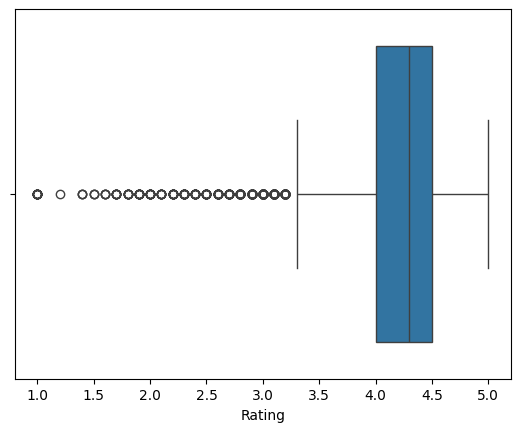

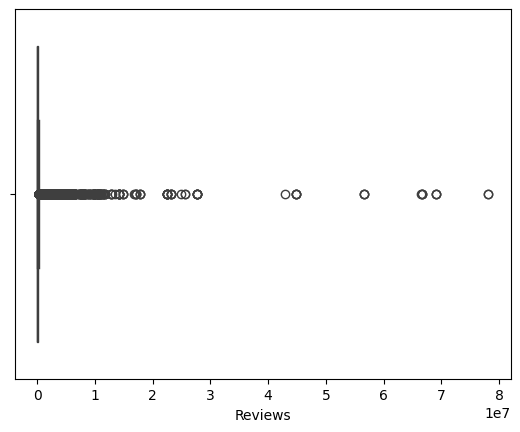

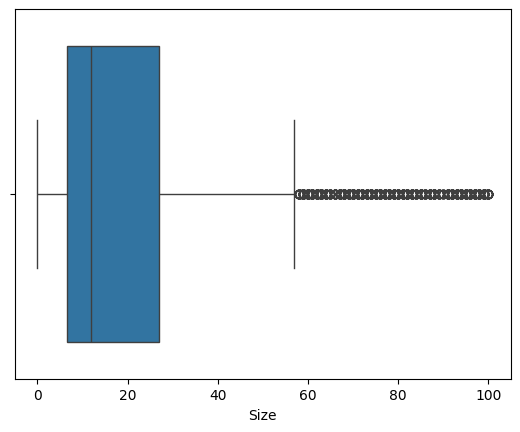

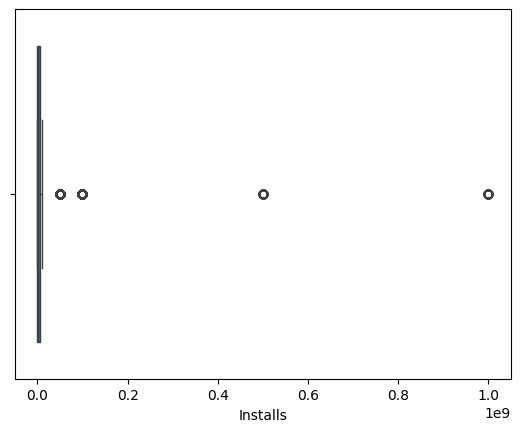

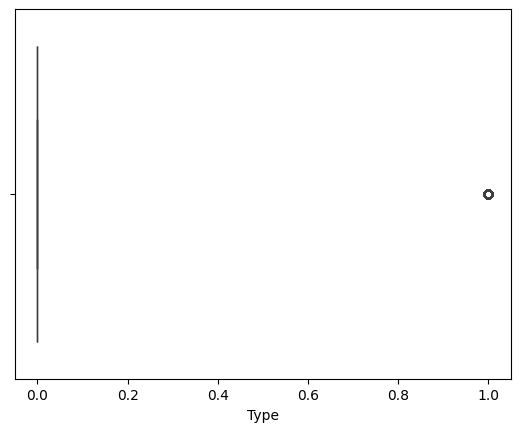

In [ ]:
for col in conti.columns: # Checking for Outliers
   sns.boxplot(x=conti[col])
   plt.show()

In [ ]:
# As per the domain knowledge we will not treat the outliers

In [ ]:
# Importing Libraries required for ML
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [ ]:
# Label Encoding (TEXT COLUMNS)

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
       df[col] = le.fit_transform(df[col])

In [ ]:
cols =df.columns
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)
df_scaled = pd.DataFrame(df_scaled, columns=cols)
df_scaled.head()

,Genre,Rating,Reviews,Size,Installs,Type,Content Rating,Android Ver
0,-2.030002,-0.178264,-0.163476,-0.094233,-0.196084,-0.272439,-0.426717,0.217233
1,-2.030002,-0.566466,-0.163219,-0.324634,-0.190714,-0.272439,-0.426717,0.217233
2,-2.030002,0.986341,-0.135694,-0.568858,-0.141395,-0.272439,-0.426717,0.217233
3,-2.030002,0.598139,-0.094942,0.182247,0.351795,-0.272439,2.610740,0.700104
4,-2.030002,0.209937,-0.163219,-0.840731,-0.195098,-0.272439,-0.426717,1.022017


In [ ]:
#H0 (Null Hypothesis):
#There is no significant difference in the average installs between Free and Paid gaming apps.

#H1 (Alternative Hypothesis):
#There is a significant difference in the average installs between Free and Paid gaming apps.

In [ ]:
# Z-Test (We are checking Whether there is a significant difference in downloads of free Vs Paid Apps)
# Two-Sample Z Test
from statsmodels.stats.weightstats import ztest # Importing Library Required for Z Test


# separate installs
free_installs = game_df[game_df['Type'] == 'Free']['Installs']
paid_installs = game_df[game_df['Type'] == 'Paid']['Installs']

# run z-test
z_stat, p_value = ztest(free_installs, paid_installs)

In [ ]:
z_stat

np.float64(2.930115239419914)

In [ ]:
p_value

np.float64(0.003388363197214338)

In [ ]:
alpha = 0.05

In [ ]:
if p_value < alpha:
  print('H0 is Rejected')
else:
    print('failed to reject H0')

H0 is Rejected


**BUSINESS DECISION**

**There is a significant difference between the downloads of the applications which are free as compared to the applications that are paid**

In [ ]:
#Null Hypothesis (H₀)

#Content Rating and App Type (Free/Paid) are independent.

#Alternative Hypothesis (Ha)

#Content Rating and App Type (Free/Paid) are dependent.

In [ ]:
# Chi-Test (we are checking whether the content Rating is Associated with the app being free or paid )
# Independence Test

from scipy.stats import chi2_contingency

table = pd.crosstab(df['Content Rating'],df['Type'])

chi2, p_value, dof, expected = chi2_contingency(table)

In [ ]:
chi2

np.float64(24.374468234793216)

In [ ]:
p_value

np.float64(5.095085463701499e-06)

In [ ]:
dof

2

In [ ]:
chi_alpha = 0.05

In [ ]:
if p_value < chi_alpha:
  print("reject  H0")
else:
    print("fail to reject H0")

reject  H0


**BUSINESS DECISON**


**The Content Rating does have direct affect on the App being free or Paid**

In [ ]:
# Feature Selection

In [ ]:
num_df = df[['Rating','Reviews','Size','Installs','Type']]

In [ ]:
corr = num_df.corr()
corr

,Rating,Reviews,Size,Installs,Type
Rating,1.000000,0.068122,0.064342,0.051328,0.039541
Reviews,0.068122,1.000000,0.097928,0.641610,-0.043300
Size,0.064342,0.097928,1.000000,0.036421,-0.016700
Installs,0.051328,0.641610,0.036421,1.000000,-0.053114
Type,0.039541,-0.043300,-0.016700,-0.053114,1.000000


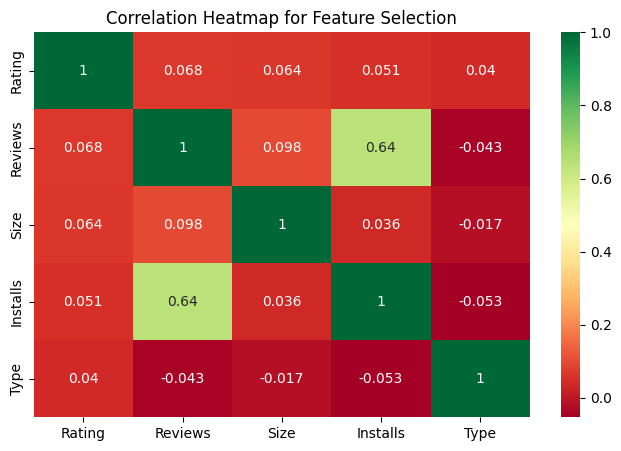

In [ ]:
plt.figure(figsize=(8,5))
sns.heatmap(corr, annot=True , cmap= 'RdYlGn')

plt.title("Correlation Heatmap for Feature Selection")

plt.show()

In [ ]:
# Splitting the data
Y = df['Type'] # Target Column
X = df.iloc[:, [i for i in range(df.shape[1]) if df.columns[i] != 'Type']] # Independent Columns

In [ ]:
X.columns

Index(['Genre', 'Rating', 'Reviews', 'Size', 'Installs', 'Content Rating',
       'Android Ver'],
      dtype='object')

In [ ]:
X_train , X_test , Y_train , Y_test = train_test_split(X,Y , train_size=0.8, random_state=42)

**STEPS OF LOGISTIC REGRESSION**

In [ ]:
# Step 1 (Build The Model)

logreg = LogisticRegression()

In [ ]:
# step 2 fit the model

logreg.fit(X_train,Y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
# Library for Evaluating Model Performance
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

In [ ]:
# Step 3 Evaluate the Training Performance
logreg.score(X_train,Y_train)

0.9281804832465625

In [ ]:
# Step 4 Predict Test Values

Y_pred = logreg.predict(X_test)


In [ ]:
print(f1_score(Y_test,Y_pred))

0.0


In [ ]:
print(confusion_matrix(Y_test,Y_pred))

[[1763    1]
 [ 109    0]]


In [ ]:
print(classification_report(Y_test, Y_pred))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97      1764
           1       0.00      0.00      0.00       109

    accuracy                           0.94      1873
   macro avg       0.47      0.50      0.48      1873
weighted avg       0.89      0.94      0.91      1873



In [ ]:
Y_proba = logreg.predict_proba(X_test) # proba means probability


print(roc_auc_score(Y_test, Y_proba[:,1])) # roc_auc_score

0.7741995880921175


No Skill: ROC AUC=0.500
Logistic: ROC AUC=0.774


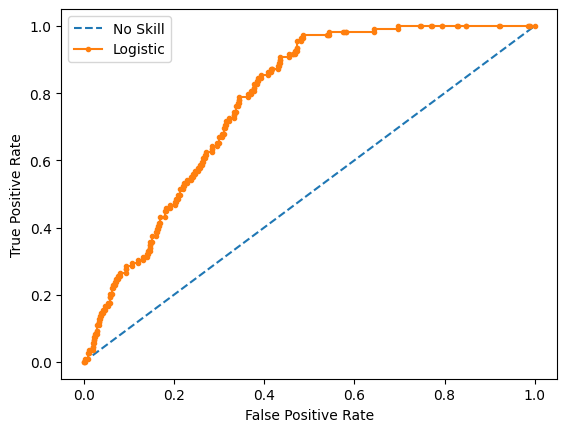

In [ ]:
from matplotlib import pyplot
# generate a no skill prediction (majority class)
ns_probs = [0 for _ in range(len(Y_test))]
# predict probabilities
y_probas = logreg.predict_proba(X_test)
# keep probabilities for the positive outcome only
lr_probs = y_probas[:,1]
# calculate scores
ns_auc = roc_auc_score(Y_test, ns_probs)
lr_auc = roc_auc_score(Y_test, lr_probs)
# summarize scores
print('No Skill: ROC AUC=%.3f' % (ns_auc))
print('Logistic: ROC AUC=%.3f' % (lr_auc))
# calculate roc curves
ns_fpr, ns_tpr, _ = roc_curve(Y_test, ns_probs)
lr_fpr, lr_tpr, _ = roc_curve(Y_test, lr_probs)
# plot the roc curve for the model
pyplot.plot(ns_fpr, ns_tpr, linestyle='--', label='No Skill')
pyplot.plot(lr_fpr, lr_tpr, marker='.', label='Logistic')
# axis labels
pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')
# show the legend
pyplot.legend()
# show the plot
pyplot.show()

In [ ]:
# Interpretation - The Model demonstarte strong classification performance
# The orange line is above the blue line (Threshold) so it is a strong model

**KNN**

In [ ]:
# Libraries for KNN
from sklearn import neighbors
from sklearn.neighbors import KNeighborsClassifier
from scipy.spatial import distance # Euclidean
from scipy.spatial.distance import cityblock # Manhattan

In [ ]:
# ML Libraries
from sklearn import neighbors
from sklearn.neighbors import KNeighborsClassifier
from scipy.spatial import distance # Euclidean
from scipy.spatial.distance import cityblock # Manhattan
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# ML Libraries for Evaluation
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import auc
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [ ]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9364 entries, 0 to 9363
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   APP_Name        9364 non-null   object 
 1   Genre           9364 non-null   object 
 2   Rating          9364 non-null   float64
 3   Reviews         9364 non-null   int64  
 4   Size            9364 non-null   object 
 5   Installs        9364 non-null   object 
 6   Type            9364 non-null   object 
 7   Price           9364 non-null   object 
 8   Content Rating  9364 non-null   object 
 9   Last Updated    9364 non-null   object 
 10  Android Ver     9362 non-null   object 
dtypes: float64(1), int64(1), object(9)
memory usage: 804.8+ KB


In [ ]:
df_copy.describe()

,Rating,Reviews
count,9364.000000,9.364000e+03
mean,4.191841,5.141595e+05
std,0.515223,3.144369e+06
min,1.000000,1.000000e+00
25%,4.000000,1.867500e+02
50%,4.300000,5.941500e+03
75%,4.500000,8.156075e+04
max,5.000000,7.815831e+07


In [ ]:
df_copy.dtypes

,0
APP_Name,object
Genre,object
Rating,float64
Reviews,int64
Size,object
Installs,object
Type,object
Price,object
Content Rating,object
Last Updated,object


In [ ]:
df_copy.drop(['Last Updated'], axis=1, inplace=True)

In [ ]:
df_copy.drop(['APP_Name '], axis=1, inplace=True)

In [ ]:
df_copy.drop(['Price'], axis=1, inplace=True)

In [ ]:
df_copy['Installs'] = df_copy['Installs'].str.replace(',', '') # removing comma from the values
df_copy['Installs'] = df_copy['Installs'].str.replace('+', '') # removing + symbol from the values
df_copy['Installs'] = df_copy['Installs'].astype(int) # changing the data type as integer

In [ ]:
def convert_size(x):
    if isinstance(x, str):
        if 'M' in x:
            return float(x.replace('M', ''))
        elif 'k' in x:
            return float(x.replace('k', '')) / 1024
    return x

df_copy['Size'] = df_copy['Size'].apply(convert_size)

In [ ]:
df_copy.head()

,Genre,Rating,Reviews,Size,Installs,Type,Content Rating,Android Ver
0,ART_AND_DESIGN,4.1,159,19.0,10000,Free,Everyone,4.0.3 and up
1,ART_AND_DESIGN,3.9,967,14.0,500000,Free,Everyone,4.0.3 and up
2,ART_AND_DESIGN,4.7,87510,8.7,5000000,Free,Everyone,4.0.3 and up
3,ART_AND_DESIGN,4.5,215644,25.0,50000000,Free,Teen,4.2 and up
4,ART_AND_DESIGN,4.3,967,2.8,100000,Free,Everyone,4.4 and up


In [ ]:
df_copy['Android Ver'].fillna(df_copy['Android Ver'].mode()[0], inplace=True)

In [ ]:
# Select numeric and categorical columns
conti2 = df_copy.select_dtypes(include="number")  # Selects all numerical columns (e.g., int, float, boolean)
categ2 = df_copy.select_dtypes(exclude="number")  # Selects all non-numerical columns (categorical, object, date, etc.)

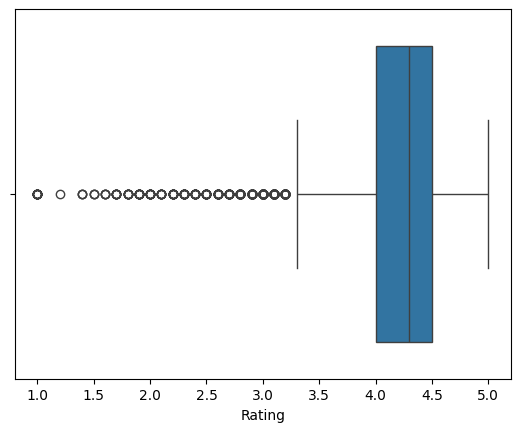

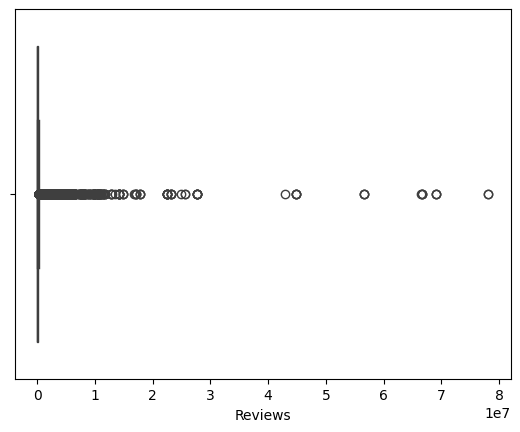

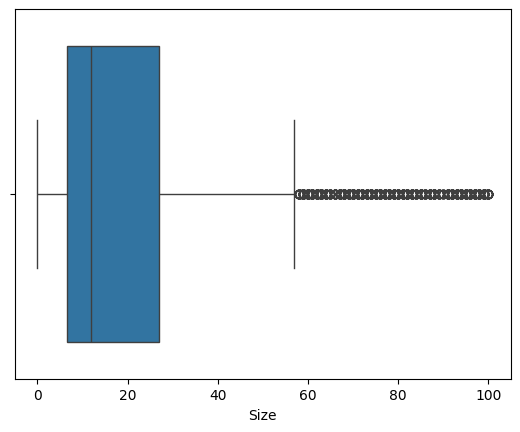

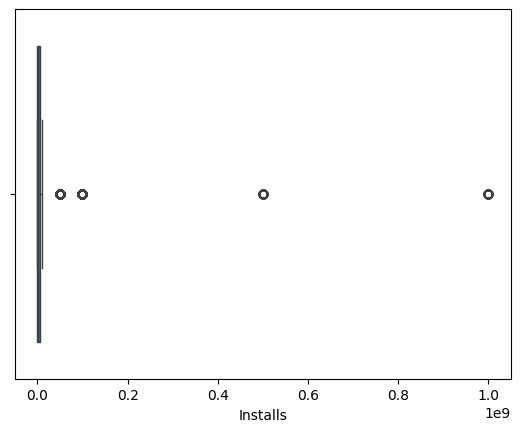

In [ ]:
for col in conti2.columns:
    sns.boxplot(x = conti[col])
    plt.show()

In [ ]:
conti2.columns

Index(['Rating', 'Reviews', 'Size', 'Installs'], dtype='object')

In [ ]:
# Create a copy of the numeric data to avoid modifying the original
no_outlier = conti2.copy()

def outlier_cleanup(col):
    # Calculate IQR and outlier fences
    q1 = no_outlier[col].quantile(0.25)
    q3 = no_outlier[col].quantile(0.75)
    iqr = q3 - q1
    lf = q1 - (1.5 * iqr)  # lower fence
    uf = q3 + (1.5 * iqr)  # upper fence

    # Check column type for proper handling of integer and float types
    col_type = str(no_outlier[col].dtype)

    # Apply outlier treatment
    if col_type in ["int64", "int32", "int16", "int8"]:
        # For integer columns, round the fence values and cast them to integers
        no_outlier.loc[no_outlier[col] < lf, col] = int(round(lf))
        no_outlier.loc[no_outlier[col] > uf, col] = int(round(uf))
    else:
        # For float columns, directly assign the fence values
        no_outlier.loc[no_outlier[col] < lf, col] = lf
        no_outlier.loc[no_outlier[col] > uf, col] = uf

In [ ]:
# Apply outlier cleanup to specific columns
for col in ['Rating', 'Reviews', 'Size', 'Installs']:
    outlier_cleanup(col)

In [ ]:
le = LabelEncoder()

for col in categ2.columns:
    if categ2[col].dtype == 'object':
       categ2[col] = le.fit_transform(categ2[col])

In [ ]:
cols = no_outlier.columns
scaler = StandardScaler()
df_scaled_2 = scaler.fit_transform(no_outlier)
df_scaled_2 = pd.DataFrame(df_scaled_2, columns=cols)
df_scaled_2.head()

,Rating,Reviews,Size,Installs
0,-0.292748,-0.680913,-0.022126,-0.680953
1,-0.771264,-0.670575,-0.311436,-0.571405
2,1.142798,0.436667,-0.618105,0.434649
3,0.664283,1.922217,0.325047,2.108051
4,0.185767,-0.670575,-0.959491,-0.660832


In [ ]:
df_clean_2 = pd.concat([df_scaled_2, categ2], axis=1)
df_clean_2

,Rating,Reviews,Size,Installs,Genre,Type,Content Rating,Android Ver
0,-0.292748,-0.680913,-0.022126,-0.680953,0,0,0,15
1,-0.771264,-0.670575,-0.311436,-0.571405,0,0,0,15
2,1.142798,0.436667,-0.618105,0.434649,0,0,0,15
3,0.664283,1.922217,0.325047,2.108051,0,0,2,18
4,0.185767,-0.670575,-0.959491,-0.660832,0,0,0,20
...,...,...,...,...,...,...,...,...
9359,-0.532006,-0.682857,-0.971063,-0.683077,11,0,0,17
9360,0.664283,-0.682461,1.945185,-0.682071,11,0,0,17
9361,1.860571,-0.682896,-0.913201,-0.683166,11,0,0,17
9362,0.664283,-0.681488,-0.427160,-0.682965,3,0,1,3


In [ ]:
y2 = df_clean_2['Type'] # Dependent column
x2 = df_clean_2.iloc[:, :5] # Independent Column

In [ ]:
x2.columns

Index(['Rating', 'Reviews', 'Size', 'Installs', 'Genre'], dtype='object')

In [ ]:
x2_train , x2_test , y2_train , y2_test = train_test_split(x2,y2 , test_size= 0.2 , random_state=42)


In [ ]:
empt = [] # creating a empty list for storing model performance
K_value = np.arange(2,20,2)
K_value

array([ 2,  4,  6,  8, 10, 12, 14, 16, 18])

In [ ]:
for final_k in K_value:
    temp = neighbors.KNeighborsClassifier(n_neighbors=final_k)
    temp = temp.fit(x2_train,y2_train)
    y2_pred = temp.predict(x2_test)
    empt.append(accuracy_score(y2_test,y2_pred)*100)
    print(f"if the value of k is {final_k} then the model acccuracy will be {accuracy_score(y2_test,y2_pred)*100}")

if the value of k is 2 then the model acccuracy will be 93.43299519487454
if the value of k is 4 then the model acccuracy will be 94.02028830752803
if the value of k is 6 then the model acccuracy will be 94.07367859049654
if the value of k is 8 then the model acccuracy will be 94.02028830752803
if the value of k is 10 then the model acccuracy will be 94.23384943940204
if the value of k is 12 then the model acccuracy will be 94.28723972237053
if the value of k is 14 then the model acccuracy will be 94.12706887346502
if the value of k is 16 then the model acccuracy will be 94.34063000533904
if the value of k is 18 then the model acccuracy will be 94.23384943940204


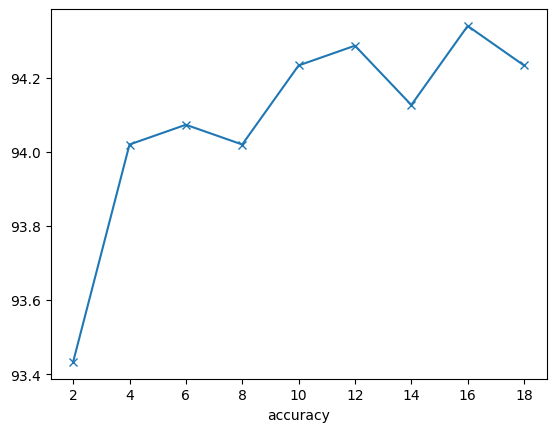

In [ ]:
plt.plot(K_value,empt,marker = 'x') # as per the elbow method the optimum K Value is 10
plt.xlabel("accuracy")
plt.show()

In [ ]:
Optimum_K = 10

In [ ]:
Knn_model = neighbors.KNeighborsClassifier(Optimum_K)

Knn_model.fit(x2_train,y2_train)

y2_pred = Knn_model.predict(x2_test)

print(accuracy_score(y2_test,y2_pred)*100)

94.23384943940204


In [ ]:
Knn_model.n_neighbors

10

In [ ]:
Knn_model.classes_

array([0, 1])

In [ ]:
y2_pred = Knn_model.predict(x2_test)

# Display first 15 predictions
print("Predicted values:", y2_pred[:15])
print("Actual values   :", y2_test.values[:15])

Predicted values: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Actual values   : [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [ ]:
print(confusion_matrix(y2_test, y2_pred))

[[1757    7]
 [ 101    8]]


In [ ]:
print(classification_report(y2_test, y2_pred))

              precision    recall  f1-score   support

           0       0.95      1.00      0.97      1764
           1       0.53      0.07      0.13       109

    accuracy                           0.94      1873
   macro avg       0.74      0.53      0.55      1873
weighted avg       0.92      0.94      0.92      1873



**After Analyzing the Model Performance of both the Models the final conclusion draws in the favour of KNN classifier as the Model performance is higher in KNN Classifier (94.23%) as compared to LogisticRegression (92.81%).**